# Introdução

: Apresentação do contexto, do modelo formal por trás da hipótese e descrição clara da própria hipótese

Contextualização da desigualdade em SP e a apresentação do **Modelo Formal**.
- **Modelo Formal:** Exemplo: $Nota = \beta_0 + \beta_1(EscolaridadePais) + \beta_2(Renda) + \epsilon$. 
- **Hipótese:** Existe uma disparidade significativa nas notas do ENEM entre diferentes zonas de SP, correlacionada com indicadores socioeconômicos locais.

# Dados

descrição da base de dados e suas principais características

carrega o CSV do ENEM e faz os primeiros filtros
- `df.info()`, `df.describe()` e `df.shape`
- Fonte
- limpeza
- estatística descritiva

Dicionário para evitar nomes errados
Retirada de colunas irrelevantes
Outliers (média no agrupamento por munícipio)

Fontes:

## Merge

In [1]:
import pandas as pd

# 1. Carregar seus dados processados do ENEM
df_enem = pd.read_csv('data/processed/enem_sp_completo_agrupado.csv')

# 2. Carregar o diretório de municípios (para garantir os nomes e siglas corretas)
df_dicionario_sp = pd.read_csv('data/raw/br_bd_diretorios_brasil_municipio.csv.gz')
df_dicionario_sp = df_dicionario_sp[df_dicionario_sp['sigla_uf'] == 'SP'][['id_municipio', 'nome']]

# 3. Carregar os dados de IDH/Infraestrutura
df_idh = pd.read_csv('data/raw/mundo_onu_adh_municipio.csv.gz')
# Filtrar apenas o ano mais recente (2010) para não duplicar linhas
df_idh = df_idh[df_idh['ano'] == 2010]

# Primeiro: Unimos o ENEM com o diretório para ter os nomes corretos das cidades
df = df_enem.merge(df_dicionario_sp, left_on='CO_MUNICIPIO_ESC', right_on='id_municipio')

# Segundo: Unimos com os dados de IDH/Infraestrutura
df = df.merge(df_idh, on='id_municipio')

# Visualizar o resultado
print(f"Total de municípios após o merge: {len(df)}")
municipios_sp = df['nome'].unique().tolist()
municipios_sp.sort()
print(f"Municípios de SP presentes no dataset: {municipios_sp}")
print(df.columns.tolist())

Total de municípios após o merge: 644
Municípios de SP presentes no dataset: ['Adamantina', 'Adolfo', 'Aguaí', 'Agudos', 'Alambari', 'Alfredo Marcondes', 'Altair', 'Altinópolis', 'Alto Alegre', 'Alumínio', 'Alvinlândia', 'Americana', 'Amparo', 'Américo Brasiliense', 'Américo de Campos', 'Analândia', 'Andradina', 'Angatuba', 'Anhembi', 'Anhumas', 'Aparecida', "Aparecida d'Oeste", 'Apiaí', 'Aramina', 'Arandu', 'Arapeí', 'Araraquara', 'Araras', 'Araçariguama', 'Araçatuba', 'Araçoiaba da Serra', 'Arco-Íris', 'Arealva', 'Areias', 'Areiópolis', 'Ariranha', 'Artur Nogueira', 'Arujá', 'Aspásia', 'Assis', 'Atibaia', 'Auriflama', 'Avanhandava', 'Avaré', 'Avaí', 'Bady Bassitt', 'Balbinos', 'Bananal', 'Barbosa', 'Bariri', 'Barra Bonita', 'Barra do Chapéu', 'Barra do Turvo', 'Barretos', 'Barrinha', 'Barueri', 'Barão de Antonina', 'Bastos', 'Batatais', 'Bauru', 'Bebedouro', 'Bento de Abreu', 'Bernardino de Campos', 'Bertioga', 'Bilac', 'Birigui', 'Biritiba-Mirim', 'Boa Esperança do Sul', 'Bocaina', 

## Feature engineering

In [2]:
df['nota_final'] = (df["NU_NOTA_CN"]+df['NU_NOTA_CH']+ df['NU_NOTA_LC'] +df['NU_NOTA_MT']+ df['NU_NOTA_REDACAO'])/5
municipios = ['Ferraz de Vasconcelos', 'Indaiatuba', 'Jundiaí', 'Itaquaquecetuba', 'São Paulo', 'Poá', 'Osasco','Guarulhos','São Bernardo' ]
for i in municipios:
    df1 = df[df['nome']== i]
    colunas = ["nome",'nota_final', "idhm"]
    print(df1[colunas])
    print("---"*30)

# Média do Brasil é 546

                      nome  nota_final   idhm
180  Ferraz de Vasconcelos  520.019765  0.738
------------------------------------------------------------------------------------------
           nome  nota_final   idhm
235  Indaiatuba  559.793855  0.788
------------------------------------------------------------------------------------------
        nome  nota_final   idhm
293  Jundiaí  575.006047  0.822
------------------------------------------------------------------------------------------
                nome  nota_final   idhm
264  Itaquaquecetuba  515.023617  0.714
------------------------------------------------------------------------------------------
          nome  nota_final   idhm
561  São Paulo  558.513053  0.805
------------------------------------------------------------------------------------------
    nome  nota_final   idhm
444  Poá  523.364329  0.771
------------------------------------------------------------------------------------------
       nome  nota_final 

In [3]:

# Colunas de interesse:
colunas = ['nome', 'nota_final', 'id_municipio', 'idhm', "idhm_e", "idhm_l", "idhm_r", "indice_frequencia_escolar", "indice_escolaridade","taxa_sem_energia_eletrica", "taxa_agua_encanada", 'taxa_atividade_15_17', 'renda_media_ocupados', 'renda_pc', 'renda_pc_pobreza_extrema', 'prop_vulner_pobreza_criancas', 'prop_pobreza', 'indice_gini', 'prop_pobreza_criancas','taxa_freq_fundamental_15_17', 'taxa_analfabetismo_15_a_17']
df_final = df[colunas].set_index(['id_municipio', 'nome'])
print(df_final.head())

                               nota_final   idhm  idhm_e  idhm_l  idhm_r  \
id_municipio nome                                                          
3500105      Adamantina        571.076814  0.790   0.750   0.852   0.772   
3500204      Adolfo            506.822308  0.730   0.648   0.844   0.710   
3500303      Aguaí             509.269302  0.715   0.606   0.858   0.703   
3500402      Águas da Prata    552.307500  0.781   0.716   0.886   0.750   
3500501      Águas de Lindóia  556.668736  0.745   0.675   0.846   0.725   

                               indice_frequencia_escolar  indice_escolaridade  \
id_municipio nome                                                               
3500105      Adamantina                            0.833                0.608   
3500204      Adolfo                                0.788                0.439   
3500303      Aguaí                                 0.690                0.467   
3500402      Águas da Prata                        0.814      

## Limpeza de dados nulos

In [4]:
#
print(df_final.isna().sum())
# Qual o nome do munícipio com nota final faltando?
municipios_faltando_nota = df_final[df_final['nota_final'].isna()].index.get_level_values('nome').unique().tolist()
print(f"Municípios com nota final faltando: {municipios_faltando_nota}")
df_final.dropna(subset=['nota_final'], inplace=True)
print(df_final.isna().sum())
# Quantidade de colunas agora:
print(f"Quantidade de linhas após remover linhas com nota final faltando: {df_final.shape[0]}")

nota_final                      1
idhm                            0
idhm_e                          0
idhm_l                          0
idhm_r                          0
indice_frequencia_escolar       0
indice_escolaridade             0
taxa_sem_energia_eletrica       0
taxa_agua_encanada              0
taxa_atividade_15_17            0
renda_media_ocupados            0
renda_pc                        0
renda_pc_pobreza_extrema        0
prop_vulner_pobreza_criancas    0
prop_pobreza                    0
indice_gini                     0
prop_pobreza_criancas           0
taxa_freq_fundamental_15_17     0
taxa_analfabetismo_15_a_17      0
dtype: int64
Municípios com nota final faltando: ['Arco-Íris']
nota_final                      0
idhm                            0
idhm_e                          0
idhm_l                          0
idhm_r                          0
indice_frequencia_escolar       0
indice_escolaridade             0
taxa_sem_energia_eletrica       0
taxa_agua_encanada 

In [5]:
# Ver se tem outliers pelo método do IQR:
Q1 = df_final['nota_final'].quantile(0.25)
Q3 = df_final['nota_final'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_final[(df_final['nota_final'] < limite_inferior) | (df_final['nota_final'] > limite_superior)]
print(f"Municípios considerados outliers: {outliers.index.get_level_values('nome').tolist()}")
# Notas consideradas outliers:
print(outliers['nota_final'].tolist())

Municípios considerados outliers: ['Álvaro de Carvalho', 'Cândido Rodrigues', 'Inúbia Paulista']
[635.6600000000001, 424.2299999999999, 622.1700000000001]


In [6]:
# Winsorização:
df_final['nota_final'] = df_final['nota_final'].clip(lower=limite_inferior, upper=limite_superior)
# Comparar as notas antes e depois da winsorização nos múnicipios considerados outliers:
df_outliers = df_final.loc[outliers.index]
print(df_outliers[['nota_final']])

                                 nota_final
id_municipio nome                          
3501400      Álvaro de Carvalho  613.724199
3510104      Cândido Rodrigues   429.643414
3520806      Inúbia Paulista     613.724199


## Estatística Descritiva

In [7]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 643 entries, (np.int64(3500105), 'Adamantina') to (np.int64(3557303), 'Estiva Gerbi')
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   nota_final                    643 non-null    float64
 1   idhm                          643 non-null    float64
 2   idhm_e                        643 non-null    float64
 3   idhm_l                        643 non-null    float64
 4   idhm_r                        643 non-null    float64
 5   indice_frequencia_escolar     643 non-null    float64
 6   indice_escolaridade           643 non-null    float64
 7   taxa_sem_energia_eletrica     643 non-null    float64
 8   taxa_agua_encanada            643 non-null    float64
 9   taxa_atividade_15_17          643 non-null    float64
 10  renda_media_ocupados          643 non-null    float64
 11  renda_pc                      643 non-null    float64
 12  

In [8]:
df_final.describe()

,nota_final,idhm,idhm_e,idhm_l,idhm_r,indice_frequencia_escolar,indice_escolaridade,taxa_sem_energia_eletrica,taxa_agua_encanada,taxa_atividade_15_17,renda_media_ocupados,renda_pc,renda_pc_pobreza_extrema,prop_vulner_pobreza_criancas,prop_pobreza,indice_gini,prop_pobreza_criancas,taxa_freq_fundamental_15_17,taxa_analfabetismo_15_a_17
count,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000
mean,520.468693,0.739622,0.676383,0.836068,0.716649,0.780037,0.512703,0.243904,96.561711,34.555754,1110.343904,714.590575,33.726656,34.769409,5.979393,0.449378,11.421182,14.571602,1.113002
std,31.870569,0.032475,0.048425,0.021939,0.040227,0.049624,0.079122,0.896514,5.100037,8.770022,281.162669,197.341499,12.378011,11.939997,4.674941,0.055845,7.420537,5.835451,0.638189
min,429.643414,0.639000,0.520000,0.775000,0.592000,0.632000,0.259000,0.000000,59.860000,7.070000,584.650000,318.440000,0.000000,7.450000,0.420000,0.330000,0.670000,0.000000,0.000000
25%,498.673709,0.719000,0.644000,0.818000,0.691000,0.748000,0.457000,0.000000,96.325000,29.115000,933.285000,588.930000,27.220000,26.405000,3.275000,0.410000,6.890000,10.440000,0.750000
50%,519.532500,0.738000,0.678000,0.837000,0.716000,0.776000,0.502000,0.060000,98.500000,33.880000,1064.240000,686.890000,34.710000,33.250000,4.750000,0.450000,9.650000,14.050000,1.060000
75%,544.693905,0.761000,0.709000,0.853000,0.740000,0.812000,0.566500,0.210000,99.310000,39.585000,1218.915000,799.335000,40.570000,41.040000,7.035000,0.485000,13.400000,17.765000,1.400000
max,613.724199,0.862000,0.825000,0.890000,0.891000,0.962000,0.762000,14.960000,100.000000,72.000000,3177.260000,2043.740000,68.890000,76.920000,35.110000,0.670000,49.400000,43.480000,6.320000


In [9]:
df_final.shape

(643, 19)

# Resultados

## Gráficos de dispersão

## Matriz de correlação

Apresentação das evidências empíricas relacionadas à hipótese (gráficos e estatísticas)

Gráficos (quais?) e o que cada um revela sobre a hipótese inicial

In [10]:
import pandas as pd
variavel_de_notas = 'nota_final'
# Calculamos a correlação pelos metodos de spearman e pearson para descobrirmos as variaveis que mais se correlacionam com a nota a fim de compará-las
spearman = df_final.corr(method='spearman')[variavel_de_notas].abs()
pearson = df_final.corr(method='pearson')[variavel_de_notas].abs()
# Visualização dos resultados do método spearman
print('Váriaveis que mais se relacionam com a nota pelo método Spearman')
maiores_spearman = spearman.drop(variavel_de_notas).sort_values(ascending=False).head(10)
print(maiores_spearman)
# Visualização dos resultados do método pearson
print('Váriaveis que mais se relacionam com a nota pelo método Pearson')
maiores_pearson = pearson.drop(variavel_de_notas).sort_values(ascending=False).head(10)
print(maiores_pearson)

Váriaveis que mais se relacionam com a nota pelo método Spearman
renda_pc                        0.598841
idhm_r                          0.598327
idhm                            0.573366
renda_media_ocupados            0.567323
indice_escolaridade             0.533906
prop_vulner_pobreza_criancas    0.442633
idhm_e                          0.433525
idhm_l                          0.419872
prop_pobreza                    0.338868
prop_pobreza_criancas           0.324932
Name: nota_final, dtype: float64
Váriaveis que mais se relacionam com a nota pelo método Pearson
idhm_r                          0.579019
renda_pc                        0.562714
idhm                            0.558804
indice_escolaridade             0.533549
renda_media_ocupados            0.522848
idhm_e                          0.419176
prop_vulner_pobreza_criancas    0.417455
idhm_l                          0.417371
prop_pobreza_criancas           0.318814
prop_pobreza                    0.311123
Name: nota_final, 

### Correlação positiva

### Correlação negativa

### Correlação fracas

In [11]:
print('Váriaveis que menos se relacionam com a nota pelo método Spearman')
menores_spearman = spearman.drop(variavel_de_notas).sort_values(ascending=True).head(10)
print(menores_spearman)
# Visualização dos resultados do método pearson
print('Váriaveis que menos se relacionam com a nota pelo método Pearson')
menores_pearson = pearson.drop(variavel_de_notas).sort_values(ascending=True).head(10)
print(menores_pearson)

Váriaveis que menos se relacionam com a nota pelo método Spearman
taxa_freq_fundamental_15_17    0.027713
taxa_atividade_15_17           0.065885
indice_frequencia_escolar      0.070811
taxa_analfabetismo_15_a_17     0.092099
taxa_sem_energia_eletrica      0.111663
renda_pc_pobreza_extrema       0.153115
taxa_agua_encanada             0.244081
indice_gini                    0.298027
prop_pobreza_criancas          0.324932
prop_pobreza                   0.338868
Name: nota_final, dtype: float64
Váriaveis que menos se relacionam com a nota pelo método Pearson
taxa_freq_fundamental_15_17    0.046806
indice_frequencia_escolar      0.067678
taxa_atividade_15_17           0.073162
taxa_analfabetismo_15_a_17     0.080640
renda_pc_pobreza_extrema       0.123104
taxa_sem_energia_eletrica      0.135308
taxa_agua_encanada             0.188008
indice_gini                    0.275881
prop_pobreza                   0.311123
prop_pobreza_criancas          0.318814
Name: nota_final, dtype: float64


## Geopandas

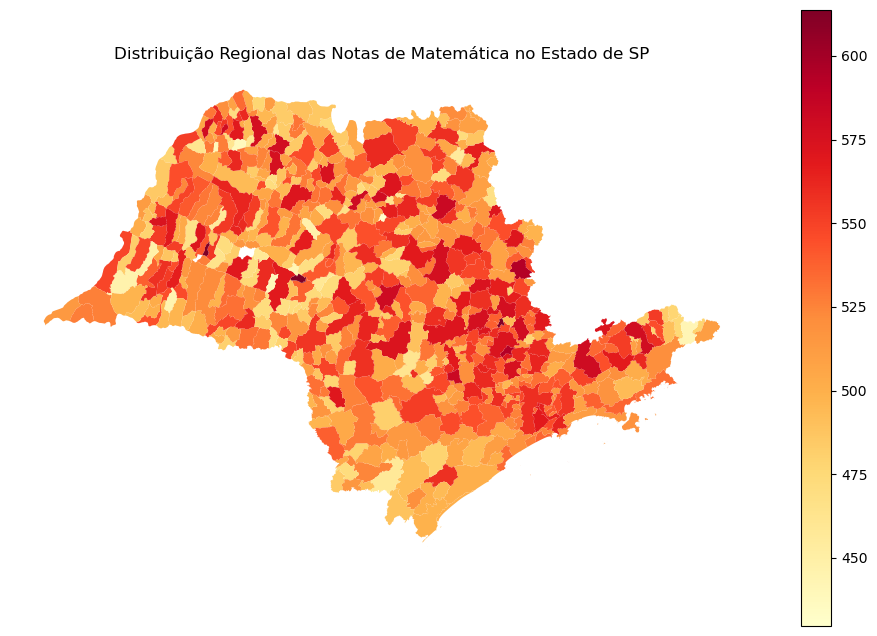

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Carregar o mapa de municípios de SP que baixou
mapa_sp = gpd.read_file('data/shp/SP_Municipios_2024.shp')

# Garantir que o ID do município é string para o cruzamento
mapa_sp['CD_MUN'] = mapa_sp['CD_MUN'].astype(str)
df_final_reset = df_final.reset_index()
df_final_reset['id_municipio'] = df_final_reset['id_municipio'].astype(str)

# Unir os dados alfanuméricos com o mapa geométrico
mapa_final = mapa_sp.merge(df_final_reset, left_on='CD_MUN', right_on='id_municipio')
# Plotar o mapa de calor da nota de Matemática
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mapa_final.plot(column='nota_final', cmap='YlOrRd', legend=True, ax=ax)
plt.title('Distribuição Regional das Notas de Matemática no Estado de SP')
plt.axis('off')
plt.show()

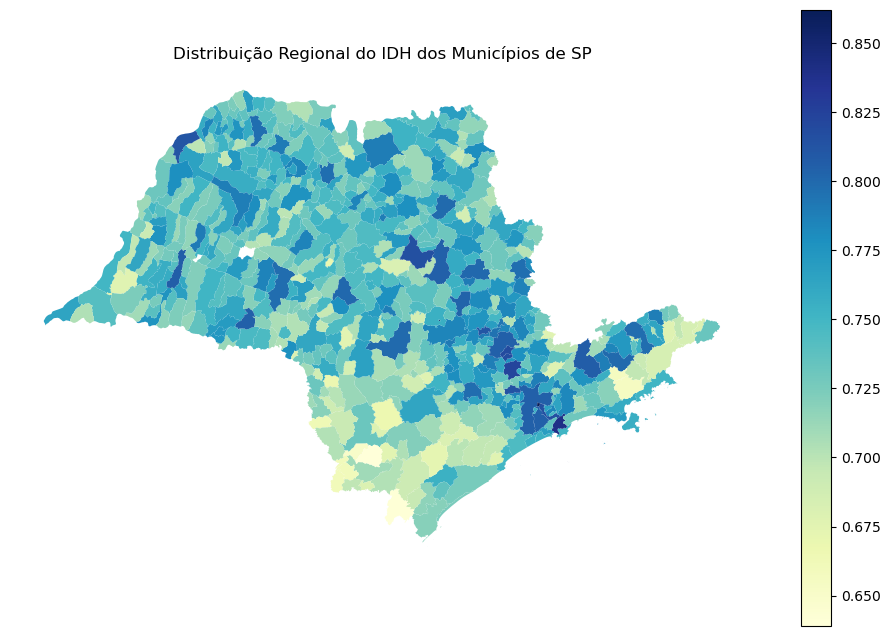

In [15]:
# Criar o mapa de calor para idh_municipio
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mapa_final.plot(column='idhm', cmap='YlGnBu', legend=True, ax=ax)
plt.title('Distribuição Regional do IDH dos Municípios de SP')
plt.axis('off')
plt.show()


# Conclusão

Considerações finais e sugestões de passos futuros para enriquecimento da análise
- evidências foram favoráveis ou contrárias à hipótese
- Sugerir aprofundamentos
